# Data Preprocessing & EDA on Insurance Dataset



In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df=pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


### Inspecting the data and finding the problems with the data 

In [3]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [4]:
df.shape

(1338, 7)

In [5]:
df.duplicated().sum()

1

In [6]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


### Handling Duplicates

In [7]:
df.drop_duplicates(inplace=True)

In [8]:
df.duplicated().sum()

0

## Exploratory Data Analysis (EDA)


<Axes: xlabel='age', ylabel='Count'>

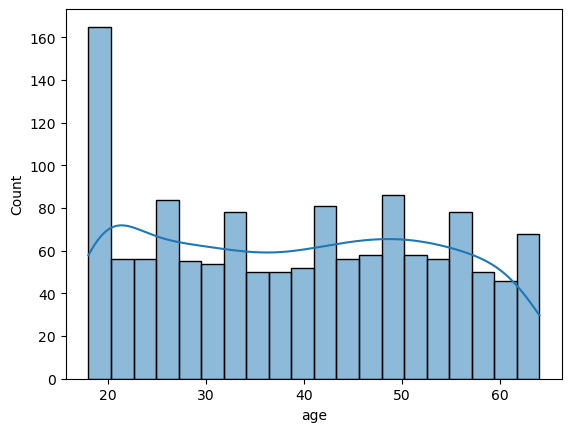

In [9]:
sns.histplot(df['age'],bins=20,kde=True)

<Axes: xlabel='age', ylabel='Density'>

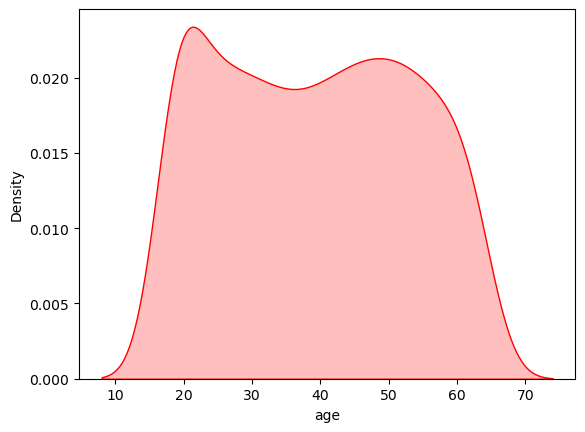

In [10]:
sns.kdeplot(df['age'],fill=True,color='red')

<Axes: xlabel='bmi', ylabel='Count'>

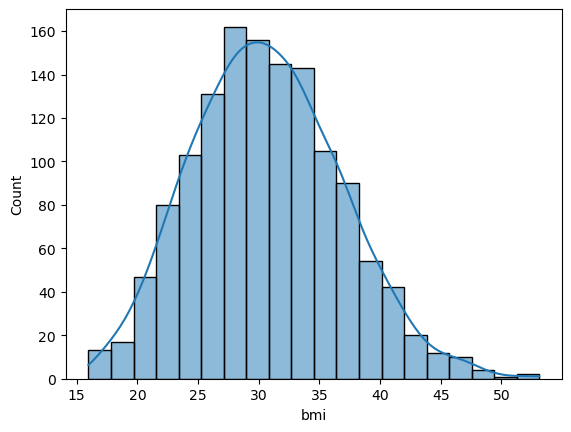

In [11]:
sns.histplot(df['bmi'],bins=20,kde=True)

<Axes: xlabel='charges', ylabel='Count'>

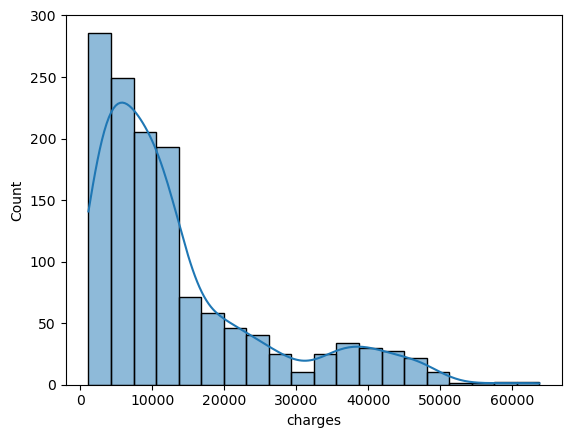

In [12]:
sns.histplot(df['charges'],bins=20,kde=True)

<Axes: xlabel='charges', ylabel='Density'>

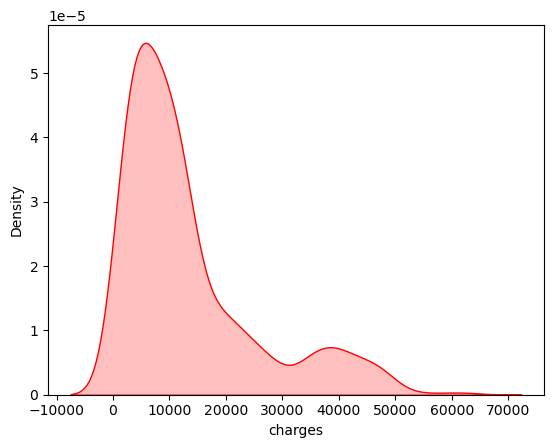

In [13]:
sns.kdeplot(df['charges'],fill=True,color='red')

## Understanding Distributions, Skewness & Outliers

When we plot variables, the **shape of their distribution** tells us a lot about the data:

| Variable | Shape we observed | Meaning |
|----------|------------------|----------|
| `charges` | **Right-skewed** (long tail on the right) | Most people pay moderate premiums, but a few pay very high amounts (often smokers / older people). |
| `bmi` | ~Normal (bell-shaped) | BMIs cluster around 25–35; few very low or very high values. |
| `age` | Almost flat / custom | People in the dataset are spread fairly evenly from 18–60+. |

---

### Why do we care about distributions?

1. **Spot unusual values (outliers)**  
   - Are they data entry errors or valid rare cases?
2. **Understand data quality**  
   - Are there missing gaps or unexpected spikes?
3. **Prepare for modelling**  
   - Some algorithms (e.g., Linear Regression, Logistic Regression, K-means) work best when variables aren’t extremely skewed.

> **Distributions are like an X-ray of your data — they reveal the hidden structure and possible “fractures”.**

---

### What to do with outliers & skewed data

| Situation | Typical action |
|-----------|----------------|
| Valid rare cases (e.g., very high `charges`) | Keep them so the model can learn about expensive claims. |
| Obvious errors (e.g., negative BMI) | Fix or drop those rows. |
| Highly skewed data for scale-sensitive models | Apply a transformation (e.g., `log`, `sqrt`) or use a **robust scaler**. |
| Tree-based models (Random Forest, XGBoost) | Usually no need to transform; they handle skew naturally. |

> Rule of thumb: if the value is **real and important**, keep it.  
> If it’s an **error or irrelevant** to the prediction task, handle or remove it.

---




### Lets see the categorical columns aswell 

In [14]:
cat_cols=['sex','smoker','region','children']

for col in cat_cols:
    print(df[col].value_counts())

male      675
female    662
Name: sex, dtype: int64
no     1063
yes     274
Name: smoker, dtype: int64
southeast    364
southwest    325
northwest    324
northeast    324
Name: region, dtype: int64
0    573
1    324
2    240
3    157
4     25
5     18
Name: children, dtype: int64


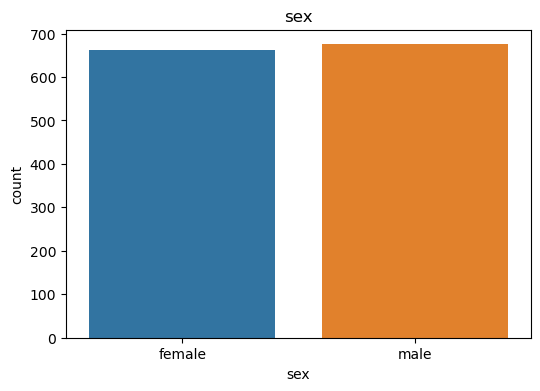

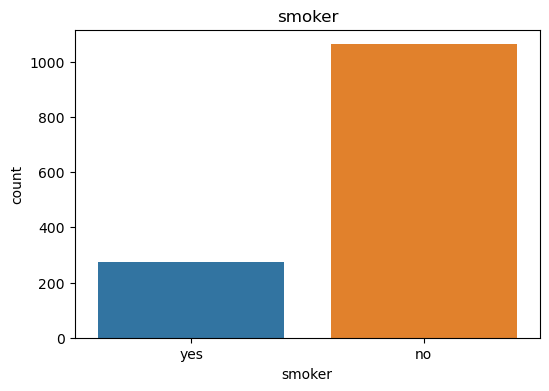

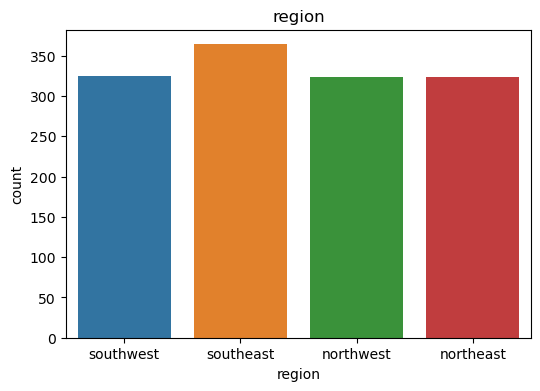

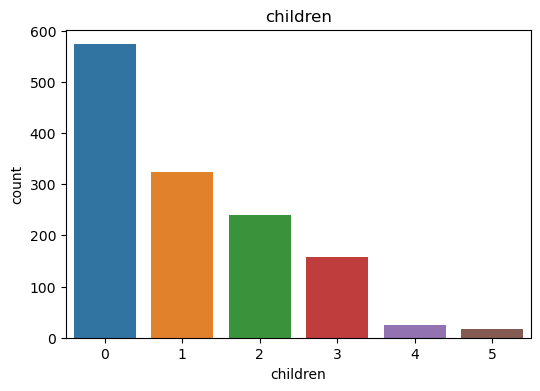

In [15]:
import matplotlib.pyplot as plt
for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col,data=df)
    plt.title(col)

<Axes: xlabel='smoker', ylabel='count'>

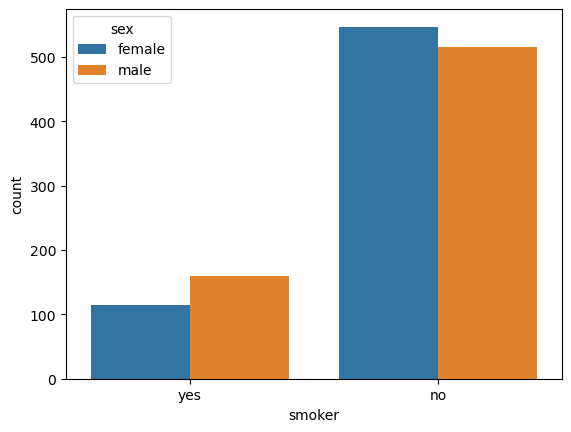

In [16]:
sns.countplot(x='smoker',data=df,hue='sex')

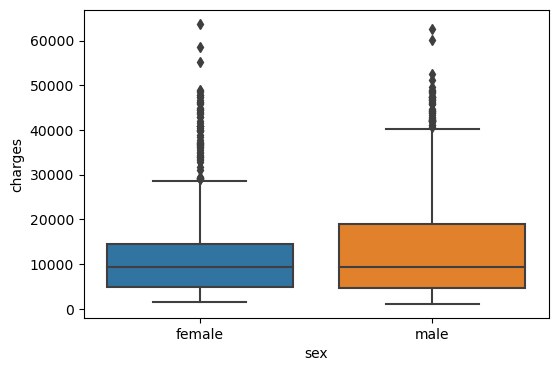

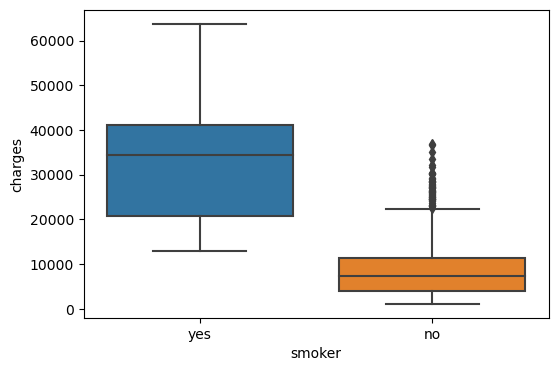

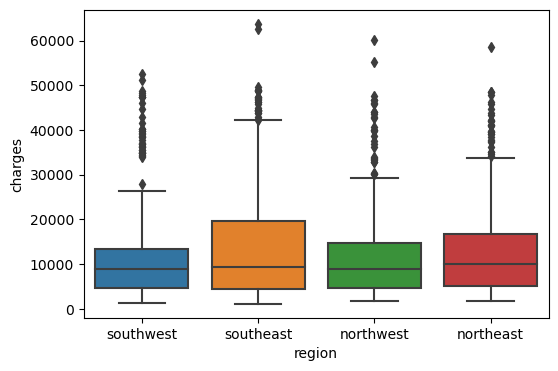

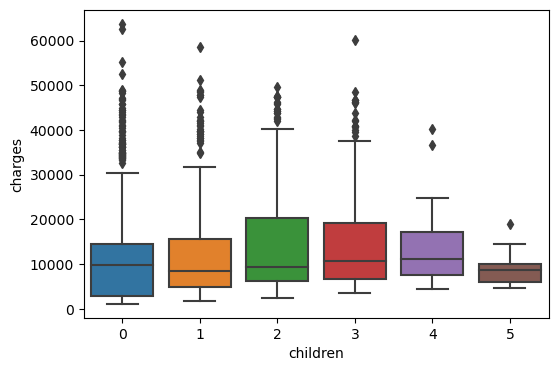

In [17]:
for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=col,y='charges',data=df)

## Insights from Categorical Variables (EDA)

After plotting and summarising the categorical columns (`sex`, `smoker`, `region`), we can interpret them as follows:

---

### 1️⃣ Frequency & Distribution
- **`sex`** – Almost evenly split between `male` and `female`.
- **`smoker`** – A smaller group (~20%) are smokers; majority are non-smokers.
- **`region`** – All four regions are represented; `southeast` has slightly more entries.

👉 These counts show how balanced each category is. Highly imbalanced classes can make a model biased, so it’s good to know the spread.

---

### 2️⃣ Charges by Category (Boxplots)
- **Smokers** have **much higher charges** than non-smokers — this is the biggest driver of insurance cost.
- **Sex** doesn’t show a strong effect on charges; both groups have similar medians.
- **Region** has only mild differences; charges are roughly similar across locations.

👉 Boxplots help us see how the target variable (`charges`) changes with each category.

---

### 3️⃣ Why this matters
- Categorical EDA tells us **which features are likely important** for prediction.
- It also reveals **imbalance** (e.g., few smokers) so we can plan resampling or careful evaluation later.
- If some categories don’t affect the target, we might simplify them or drop them in feature engineering.

> **Summary:**  
> - `smoker` is a strong predictor of `charges`.  
> - `region` and `sex` show only weak effects.  
> - All categories are clean (no missing or weird labels).


#  Prepare Data for Machine Learning 
Once EDA is done, you use those insights to make the dataset model-ready.
Encode Categorical Variables

Convert non-numeric columns (sex, smoker, region) into numbers so algorithms can understand them.


## Encoding Categorical Variables: One-Hot vs Label Encoding

Most machine-learning algorithms can’t handle text directly — they need numbers.  
To convert categories → numbers, we usually use **Label Encoding** or **One-Hot Encoding**.

---

### 1️⃣ Label Encoding
- **What it does:** Assigns an integer to each category.  
  Example for `region`:
  | region     | encoded |
  |------------|---------|
  | northeast  | 0 |
  | northwest  | 1 |
  | southeast  | 2 |
  | southwest  | 3 |

- **When to use:**
  - If the variable is **ordinal** (has a natural order):  
    e.g., `education_level` = {High School < Bachelor < Master < PhD}
  - Tree-based models (Decision Tree, Random Forest, XGBoost) can also handle label-encoded data because they don’t assume any linear relationship.

- **Risk:** For non-ordinal data, numbers may imply a false order (e.g., “male=0, female=1” could make a regression think 1 > 0).

---

### 2️⃣ One-Hot Encoding
- **What it does:** Creates new binary columns — one for each category.  
  Example for `region`:
  | northeast | northwest | southeast | southwest |
  |-----------|-----------|-----------|-----------|
  | 1 | 0 | 0 | 0 |
  | 0 | 1 | 0 | 0 |
  | 0 | 0 | 1 | 0 |

- **When to use:**
  - For **nominal** (unordered) variables, like `region`, `color`, `smoker`.
  - For linear models or distance-based algorithms (KNN, SVM, Logistic/Linear Regression).

- **Tip:** Use `drop_first=True` in `pd.get_dummies()` to avoid the *dummy variable trap* (perfect multicollinearity).

---

### ✅ Rule of Thumb

| Variable type | Preferred encoding |
|---------------|-------------------|
| Ordinal (ordered) | **Label Encoding** |
| Nominal (unordered) | **One-Hot Encoding** |

> If unsure, use **One-Hot** — it’s safe (just increases the number of columns).

---


In [18]:
df_encoded=pd.get_dummies(df,columns=['sex','smoker','region'],drop_first=True)
df_encoded=df_encoded.astype(int)

In [19]:
df_encoded

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27,0,16884,0,1,0,0,1
1,18,33,1,1725,1,0,0,1,0
2,28,33,3,4449,1,0,0,1,0
3,33,22,0,21984,1,0,1,0,0
4,32,28,0,3866,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...
1333,50,30,3,10600,1,0,1,0,0
1334,18,31,0,2205,0,0,0,0,0
1335,18,36,0,1629,0,0,0,1,0
1336,21,25,0,2007,0,0,0,0,1


### Scale / Normalize Numerical Features

Some algorithms (Linear/Logistic Regression, KNN, SVM, Neural Nets) are sensitive to feature scales.
👉 Apply StandardScaler or MinMaxScaler to columns like age, bmi, children, charges.

In [20]:
from sklearn.preprocessing import StandardScaler

In [21]:
scaler=StandardScaler()
cols=['age','children','bmi']
df_encoded[cols]=scaler.fit_transform(df_encoded[cols])
df_encoded

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,-1.440418,-0.517949,-0.909234,16884,0,1,0,0,1
1,-1.511647,0.462463,-0.079442,1725,1,0,0,1,0
2,-0.799350,0.462463,1.580143,4449,1,0,0,1,0
3,-0.443201,-1.334960,-0.909234,21984,1,0,1,0,0
4,-0.514431,-0.354547,-0.909234,3866,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...
1333,0.767704,-0.027743,1.580143,10600,1,0,1,0,0
1334,-1.511647,0.135659,-0.909234,2205,0,0,0,0,0
1335,-1.511647,0.952670,-0.909234,1629,0,0,0,1,0
1336,-1.297958,-0.844753,-0.909234,2007,0,0,0,0,1


## Data Division

In [22]:
X=df_encoded.drop('charges',axis=1)
Y=df_encoded['charges']


In [23]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

## Train the Model


In [24]:
model_encoded=LinearRegression()
model_encoded

LinearRegression()

Text(0, 0.5, 'Actual Values')

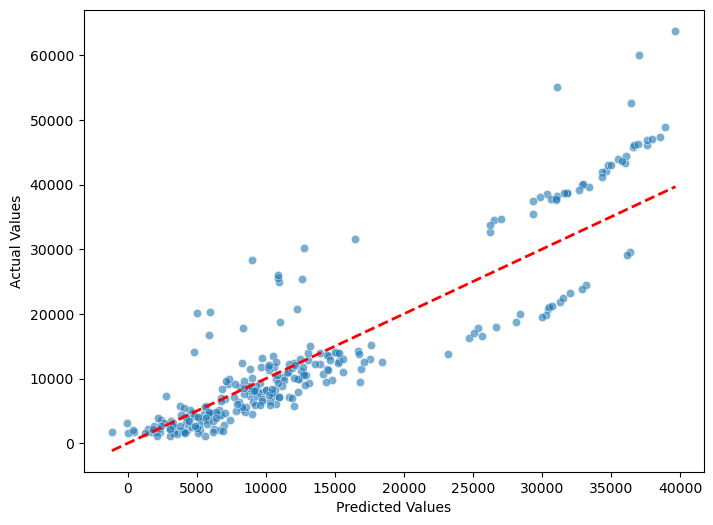

In [25]:
model_encoded.fit(X_train,Y_train)
y_pred=model_encoded.predict(X_test)
plt.figure(figsize=(8,6))
sns.scatterplot( x=y_pred, y=Y_test, alpha=0.6)
plt.plot([y_pred.min(), y_pred.max()], [y_pred.min(), y_pred.max()], 'r--', lw=2)
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')

In [26]:
from sklearn.metrics import mean_squared_error,r2_score

print(mean_squared_error(y_pred,Y_test))
r2=r2_score(y_pred,Y_test)

n=df_encoded.shape[0]
p=df_encoded.shape[1]

adjusted_r2=1-((1-r2)*(n-1))/(n-p-1)
adjusted_r2

35475294.142911285


0.6878782047932307

## Check for Overfitting

In [27]:
y_pred_new=model_encoded.predict(X_train)
print(mean_squared_error(y_pred_new,Y_train))
r2=r2_score(y_pred_new,Y_train)

adjusted_r2=1-((1-r2)*(n-1))/(n-p-1)
adjusted_r2

36984867.28114135


0.6273815281789252

## Ridge Regression

In [28]:
from sklearn.linear_model import Ridge

ridge=Ridge()

ridge.fit(X_train,Y_train)
y_pred_rid=ridge.predict(X_test)

r2=r2_score(Y_test,y_pred_rid)
print(r2)

adjusted_r2=1-((1-r2)*(n-1))/(n-p-1)
adjusted_r2

0.8059335442151715


0.8046173436861108

## Polynomial Regression

In [29]:
from sklearn.preprocessing import PolynomialFeatures


poly=PolynomialFeatures(degree=2)

X_train_poly=poly.fit_transform(X_train)
X_test_poly=poly.fit_transform(X_test)


model_poly=LinearRegression()

model_poly.fit(X_train_poly,Y_train)
y_pred_poly=model_poly.predict(X_test_poly)

r2=r2_score(Y_test,y_pred_poly)
print(r2)

adjusted_r2=1-((1-r2)*(n-1))/(n-p-1)
adjusted_r2


0.8818616055167818


0.8810603654637683

In [30]:
# Check for overfitting
print("Train R²:", model_poly.score(X_train_poly, Y_train))  
print("Test R²:", model_poly.score(X_test_poly, Y_test))     



Train R²: 0.8345800241771156
Test R²: 0.8818616055167818


## Model Saving

In [37]:
import joblib
joblib.dump(model_poly, 'insurance_model.pkl')
loaded_model = joblib.load('insurance_model.pkl')
test_pred = loaded_model.predict(X_test_poly)
print(r2_score(Y_test, test_pred))  # Verify

0.8818616055167818


## Feature Importance

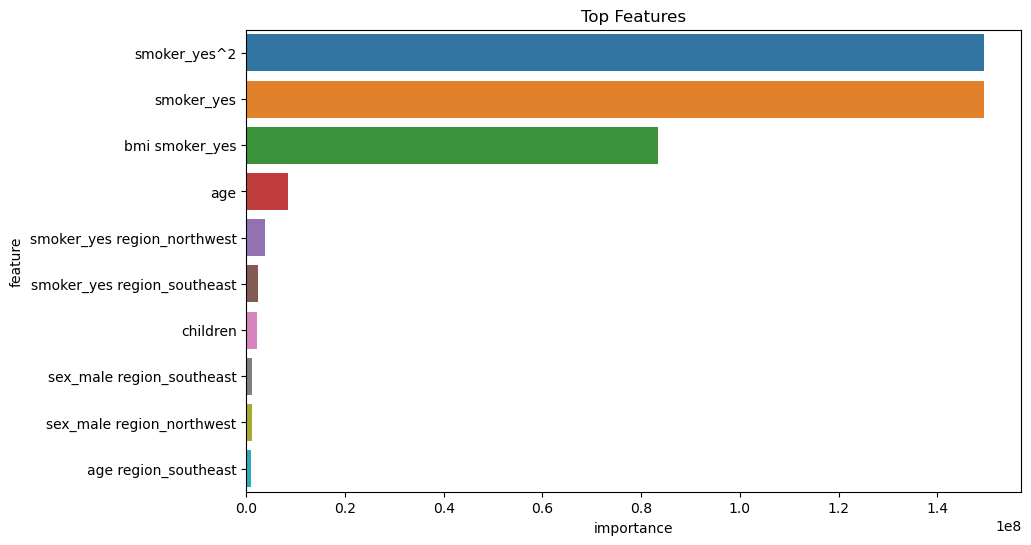

In [44]:

poly_feature_names = poly.get_feature_names_out()  
poly_feature_names = poly.get_feature_names_out(poly.feature_names_in_)

importances = model_poly.coef_ ** 2
feat_importance = pd.DataFrame({
    'feature': poly_feature_names, 
    'importance': importances
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=feat_importance.head(10), x='importance', y='feature')
plt.title('Top Features')
plt.show()

## Cross Validation

In [47]:
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(model_poly, X_train_poly, Y_train, cv=5, scoring='r2')
print(f'CV R²: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')

CV R²: 0.823 ± 0.025
